# Business Understanding

## Background

* The AIC Kijabe hospital's outpatient department (OPD) currently manages patient flow across approximately forty departments (General OPD, Casualty, Renal, Oncology, and others) without a structured way to anticipate periods of high patient volume. This can lead to under-staffing during surges and inefficient resource allocation during quieter periods.

## Business Objectives

* Enable the hospital to anticipate periods of higher patient volume in advance, so that staffing and resources can be planned proactively rather than reactively.
* Understand whether seasonal patterns (i.e rainy vs dry seasons in Kenya) affect patient volume, to support longer-term capacity planning.
* Understand patient return behavior (how long patients typically go before returning to the hospital) to support follow-up care planning and identify departments with outlying short or long return intervals.

## Data Analysis Goals

* Build a time series forecasting model to predict daily department-level patient arrival volume.
* Quantify the relationship between seasonal patterns and patient volume, including any lagged effects.
* Apply survival analysis to model time-to-return-visit, since discharge/exit data is not available in this dataset, return-visit interval is used as a signal for patient care continuity.

## Success Criteria

* Surge model - Forecast accuracy to be more useful than a simple "same as last week" baseline (e.g., a measurable improvement in MAE/RMSE).
* Seasonal correlation - A clear, evidence-based statement on whether seasons have a meaningful effect on patient volume.
* Survival analysis - Identifiable differences in return-visit patterns across at least one patient segment (e.g., department, age group).

# Data Preparation

In [2]:
#%pip install openpyxl

In [3]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
# load the data
data = pd.read_excel("Opd_data.xlsx")
data.head()

,PatientNumber,RegistrationDate,Gender,Age,QueuedTo,ConsultDescription
0,010575758,2024-06-01 00:00:00.000,Male,38 Yr(s),GENERAL OPD,GEneral Outpatient Care( NEW )
1,010575713,2024-06-01 00:00:00.000,Female,29 Yr(s),NaN,NaN
2,010569291,2024-06-01 00:04:38.083,Female,44 Yr(s),GENERAL OPD,General Outpatient Care
3,010575732,2024-06-01 00:04:42.460,Female,78 Yr(s),GENERAL OPD,General Outpatient Care
4,010575731,2024-06-01 00:10:16.037,Female,2 Yr(s),ADMISSION,Admission


In [5]:
# Basic exploratory
data.shape
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306306 entries, 0 to 306305
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       306306 non-null  object        
 1   RegistrationDate    306306 non-null  datetime64[ns]
 2   Gender              306291 non-null  object        
 3   Age                 305735 non-null  object        
 4   QueuedTo            299528 non-null  object        
 5   ConsultDescription  299920 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 14.0+ MB
None


## Data Cleaning

In [6]:
# Check for missing values
data.isnull().sum()

PatientNumber            0
RegistrationDate         0
Gender                  15
Age                    571
QueuedTo              6778
ConsultDescription    6386
dtype: int64

In [7]:
# check for duplicates
data.duplicated().sum()

np.int64(355)

In [8]:
# Drop the duplicates
data= data.drop_duplicates()

In [9]:
# Recheck for duplicates
data.duplicated().sum()

np.int64(0)

In [10]:
# Drop gender null values
data = data[data['Gender'].notna()]

In [11]:
# Standardize casing
data['Gender'] = data['Gender'].str.strip().str.upper()

## Age In Years

In [12]:
# extract the number and the unit separately
data['AgeNum'] = data['Age'].str.extract(r'(\d+)').astype(float)
# the numeric part, 38
data['AgeUnit'] = data['Age'].str.extract(r'\d+\s*(\D+)')[0].str.strip()  
# the unit part, "Yr(s)"

# convert based on unit: years stay the same, months divide by 12, weeks divide by 52, days divide by 365
conditions = [
    data['AgeUnit'] == 'Yr(s)',
    data['AgeUnit'] == 'Mth(s)',
    data['AgeUnit'] == 'Week(s)',
    data['AgeUnit'] == 'Days(s)'
]
choices = [
    data['AgeNum'],
    data['AgeNum'] / 12,
    data['AgeNum'] / 52,
    data['AgeNum'] / 365
]
data['AgeYears'] = np.select(conditions, choices, default=np.nan)

# round to 2 decimal places
data['AgeYears'] = data['AgeYears'].round(2)  

# only interested in age years
data = data.drop(columns=['AgeNum', 'AgeUnit'])


In [13]:
# Turning all impossible ages (>100)into NAN
data.loc[data['AgeYears'] > 100, 'AgeYears'] = np.nan

In [14]:
# calculate the mean age from all remaining valid values (this naturally excludes 
# both the >100 values we just nulled and any age that was already missing)
mean_age = round(data['AgeYears'].mean(), 2)
print(round(mean_age, 2))

40.86


In [15]:
# impute missing ages with mean
data['AgeYears'] = data['AgeYears'].fillna(mean_age)

print(mean_age)
# print(data['Age_num'].isna().sum())
print(data['AgeYears'].isna().sum())

40.86
0


In [16]:
# Bin into ages groups
data['AgeGroup']  = pd.cut(
    data['AgeYears'],                                    
    bins=[0,5,12,18,35,60,100],
    labels=['Infant(0-5)','Child(6-12)','Teen(13-18)','Young Adult(19-35)','Adult(36-60)','Senior(61-100)'],
    include_lowest=True
)

In [17]:
# Drop missing QueuedTo
data = data.dropna(subset=['QueuedTo'])

In [18]:
# Clean the QueuedTo column
data['QueuedTo']= data['QueuedTo'].str.strip().str.upper()

In [19]:
# Drop the age column
data = data.drop(columns=['Age'])

In [20]:
# Rechecking the null values
data.isna().sum()

PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
dtype: int64

In [21]:
data[data['AgeGroup'].isna()]['AgeYears'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: AgeYears, dtype: float64

In [22]:
data['AgeGroup'].unique()

['Adult(36-60)', 'Senior(61-100)', 'Infant(0-5)', 'Young Adult(19-35)', 'Child(6-12)', 'Teen(13-18)']
Categories (6, object): ['Infant(0-5)' < 'Child(6-12)' < 'Teen(13-18)' < 'Young Adult(19-35)' < 'Adult(36-60)' < 'Senior(61-100)']

In [23]:
# Recheck everything
print("Shape:", data.shape)
print()
print("Missing values:")
print(data.isnull().sum())
print()
print("Duplicate rows:", data.duplicated().sum())
print()
print("Dtypes:")
print(data.dtypes)
print()
print("Age range check:", data['AgeYears'].min(), "-", data['AgeYears'].max())
## print("Age range check:", data['Age_num'].min(), "-", data['Age_num'].max())
print()
print("Columns:", list(data.columns))

Shape: (299162, 7)

Missing values:


PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
dtype: int64

Duplicate rows: 0

Dtypes:
PatientNumber                 object
RegistrationDate      datetime64[ns]
Gender                        object
QueuedTo                      object
ConsultDescription            object
AgeYears                     float64
AgeGroup                    category
dtype: object

Age range check: 0.0 - 100.0

Columns: ['PatientNumber', 'RegistrationDate', 'Gender', 'QueuedTo', 'ConsultDescription', 'AgeYears', 'AgeGroup']


In [24]:
# Exploring the data
data['QueuedTo'].unique()

array(['GENERAL OPD', 'ADMISSION', 'CASUALTY', 'GEN SURG OPD', 'RENAL',
       'MCH', 'PHYSIOTHERAPY', 'DAYCASE', 'DENTAL', 'SPECIALITY CLINIC',
       'PSYCHOLOGY', 'OHNS', 'ONCOLOGY', 'PRIVATE CLINIC', 'EYE CLINIC',
       'PAEDS BKKH', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'ORTHO OPD',
       'PALLIATIVE', 'AUDIOLOGY', 'NUTRITION', 'OCCUPATIONAL THERAPY',
       'NEURO SURGERY CONSULTATION', 'FAMILY MEDICINE', 'DIABETIC CLINIC',
       'FAMILY CLINIC', 'GYNAE OPD', 'MATERNITY NURSERY', 'TELEMEDICINE',
       'MORGUE', 'CARDIOLOGY', 'KJ000104/19', 'PAEDS',
       'RESPIRATORY CENTER', 'HTS', 'PATHOLOGY', 'MENTAL HEALTH',
       'NAIVASHA TOWN CLINIC', 'MEB SPECIALITY CLINIC', 'NEUROSURGERY',
       'PEDIATRIC NEUROLOGY', 'MEB PHYSIOTHERAPY', 'ANAESTHESIA', 'ALL'],
      dtype=object)

# Data Exploration

In [25]:
# Exploring the data
data['QueuedTo'].unique()

array(['GENERAL OPD', 'ADMISSION', 'CASUALTY', 'GEN SURG OPD', 'RENAL',
       'MCH', 'PHYSIOTHERAPY', 'DAYCASE', 'DENTAL', 'SPECIALITY CLINIC',
       'PSYCHOLOGY', 'OHNS', 'ONCOLOGY', 'PRIVATE CLINIC', 'EYE CLINIC',
       'PAEDS BKKH', 'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)', 'ORTHO OPD',
       'PALLIATIVE', 'AUDIOLOGY', 'NUTRITION', 'OCCUPATIONAL THERAPY',
       'NEURO SURGERY CONSULTATION', 'FAMILY MEDICINE', 'DIABETIC CLINIC',
       'FAMILY CLINIC', 'GYNAE OPD', 'MATERNITY NURSERY', 'TELEMEDICINE',
       'MORGUE', 'CARDIOLOGY', 'KJ000104/19', 'PAEDS',
       'RESPIRATORY CENTER', 'HTS', 'PATHOLOGY', 'MENTAL HEALTH',
       'NAIVASHA TOWN CLINIC', 'MEB SPECIALITY CLINIC', 'NEUROSURGERY',
       'PEDIATRIC NEUROLOGY', 'MEB PHYSIOTHERAPY', 'ANAESTHESIA', 'ALL'],
      dtype=object)

In [26]:
data['QueuedTo'].value_counts(dropna=False)

QueuedTo
GENERAL OPD                            85620
ADMISSION                              33876
MCH                                    29451
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25365
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
MEB SPECIALITY CLINIC                  13523
RENAL                                  11103
PAEDS BKKH                              9731
DENTAL                                  9252
DAYCASE                                 7596
OHNS                                    7290
EYE CLINIC                              6026
PHYSIOTHERAPY                           5825
GEN SURG OPD                            5155
CASUALTY                                3460
PRIVATE CLINIC                          3075
AUDIOLOGY                               1379
PSYCHOLOGY                              1223
NEUROSURGERY                            1032
OCCUPATIONAL THERAPY                     815
NUTRITION                                752
T

In [27]:
# 1. Drop the 3 one-off data errors
data = data[~data['QueuedTo'].isin(['KJ000104/19', 'Naivasha Town Clinic', 'All'])]

# 2. Flag admissions separately (so you can exclude/include as needed per analysis)
data['IsAdmission'] = data['QueuedTo'] == 'ADMISSION'


In [28]:
# Feature engineering
data['DayOfWeek'] = data['RegistrationDate'].dt.day_name()
data['IsWeekend'] = data['RegistrationDate'].dt.dayofweek >= 5
data['Month'] = data['RegistrationDate'].dt.month_name()
data['Date'] = data['RegistrationDate'].dt.date
data['Year'] = data['RegistrationDate'].dt.year
data['Hour'] = data['RegistrationDate'].dt.hour

data[['RegistrationDate', 'DayOfWeek', 'IsWeekend', 'Month', 'Hour', 'Year', 'Date']].head()

,RegistrationDate,DayOfWeek,IsWeekend,Month,Hour,Year,Date
0,2024-06-01 00:00:00.000,Saturday,True,June,0,2024,2024-06-01
2,2024-06-01 00:04:38.083,Saturday,True,June,0,2024,2024-06-01
3,2024-06-01 00:04:42.460,Saturday,True,June,0,2024,2024-06-01
4,2024-06-01 00:10:16.037,Saturday,True,June,0,2024,2024-06-01
5,2024-06-01 01:22:53.050,Saturday,True,June,1,2024,2024-06-01


In [29]:
# confirm this is ok
print(data.shape)
print(data.isna().sum())

(299161, 14)
PatientNumber         0
RegistrationDate      0
Gender                0
QueuedTo              0
ConsultDescription    0
AgeYears              0
AgeGroup              0
IsAdmission           0
DayOfWeek             0
IsWeekend             0
Month                 0
Date                  0
Year                  0
Hour                  0
dtype: int64


In [54]:
# Top 5 deparrtments, everything else grouped others
Top_Departments = [
    'GENERAL OPD',
    'CHRONIC CARE CLINIC (DM/HTN/TB/CCC)',
    'MCH',
    'SPECIALITY CLINIC',
    'ONCOLOGY'
]

data['QueuedTo_Grouped'] = data['QueuedTo'].where(
    data['QueuedTo'].isin(Top_Departments)
)

data['QueuedTo_Grouped'].value_counts()

QueuedTo_Grouped
GENERAL OPD                            85620
MCH                                    29451
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    25365
SPECIALITY CLINIC                      22356
ONCOLOGY                               13606
Name: count, dtype: int64

In [55]:
# Exclude admission completely
data_opd_only = data[~data['IsAdmission']]

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299161 entries, 0 to 306305
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   PatientNumber       299161 non-null  object        
 1   RegistrationDate    299161 non-null  datetime64[ns]
 2   Gender              299161 non-null  object        
 3   QueuedTo            299161 non-null  object        
 4   ConsultDescription  299161 non-null  object        
 5   AgeYears            299161 non-null  float64       
 6   AgeGroup            299161 non-null  category      
 7   IsAdmission         299161 non-null  bool          
 8   DayOfWeek           299161 non-null  object        
 9   IsWeekend           299161 non-null  bool          
 10  Month               299161 non-null  object        
 11  Date                299161 non-null  object        
 12  Year                299161 non-null  int32         
 13  Hour                299161 non-nul

## EDA

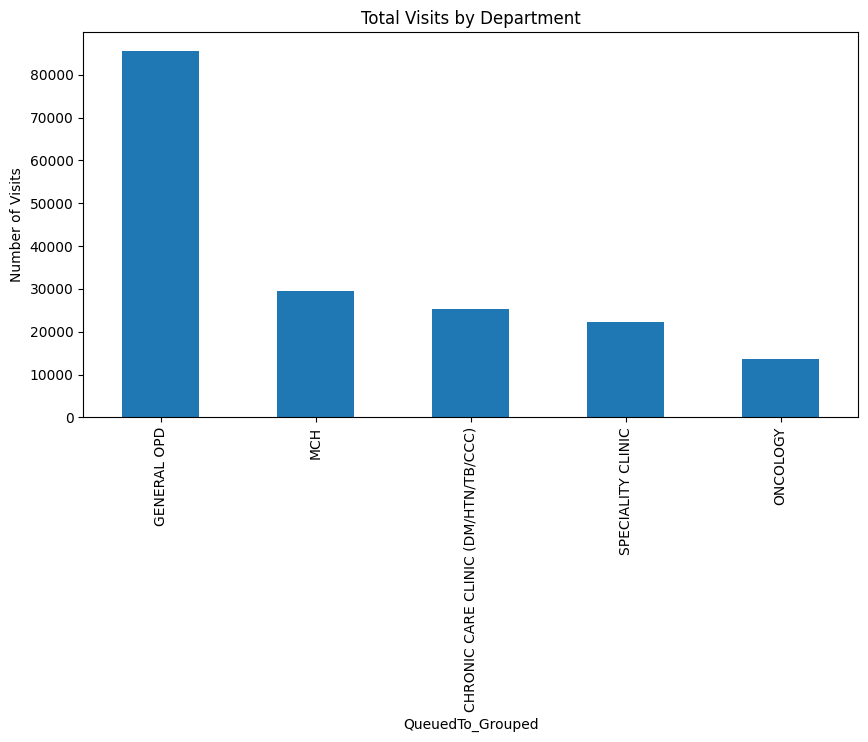

In [57]:
# Total visit volume by department
Total_dept = data['QueuedTo_Grouped'].value_counts()
Total_dept.plot(kind='bar', figsize=(10,5), title='Total Visits by Department')
plt.ylabel('Number of Visits')
plt.show()

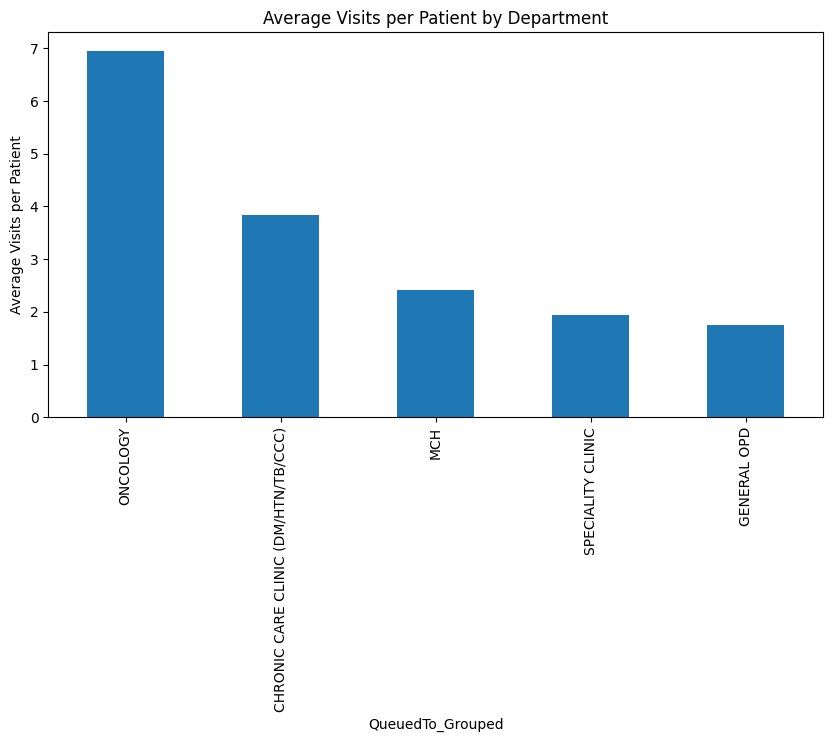

QueuedTo_Grouped
ONCOLOGY                               6.956033
CHRONIC CARE CLINIC (DM/HTN/TB/CCC)    3.832729
MCH                                    2.422156
SPECIALITY CLINIC                      1.939951
GENERAL OPD                            1.742227
Name: visits, dtype: float64

In [58]:
# Average visits per patient,by department
visits_per_patient_by_dept = data.groupby(['QueuedTo_Grouped', 'PatientNumber']).size().reset_index(name='visits')
avg_visits_by_dept = visits_per_patient_by_dept.groupby('QueuedTo_Grouped')['visits'].mean().sort_values(ascending=False)

avg_visits_by_dept.plot(kind='bar', figsize=(10,5), title='Average Visits per Patient by Department')
plt.ylabel('Average Visits per Patient')
plt.show()

avg_visits_by_dept

#### Observation
oncology patients has the highest number of repeated visits more than any departments,followed by chronic care clinic

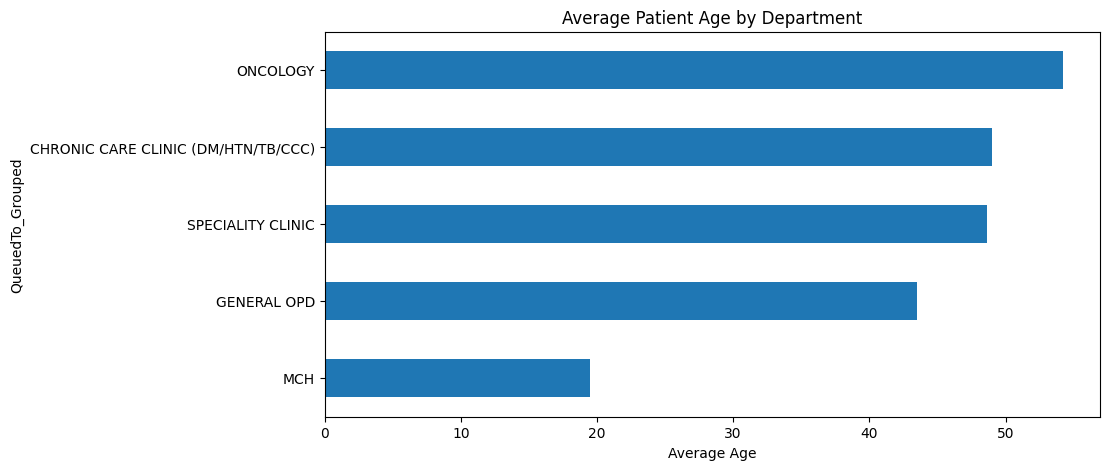

In [59]:
# Average patient age by department

# avg_age_by_dept = data.groupby('QueuedTo_Grouped')['Age_num'].mean().sort_values()
avg_age_by_dept = data.groupby('QueuedTo_Grouped')['AgeYears'].mean().sort_values()
avg_age_by_dept.plot(kind='barh', figsize=(10,5), title='Average Patient Age by Department')
plt.xlabel('Average Age')
plt.show()

### Observation
Average patient age varies meaningfully by department, from 22 years in Maternal Child Health to 54 years in oncology,

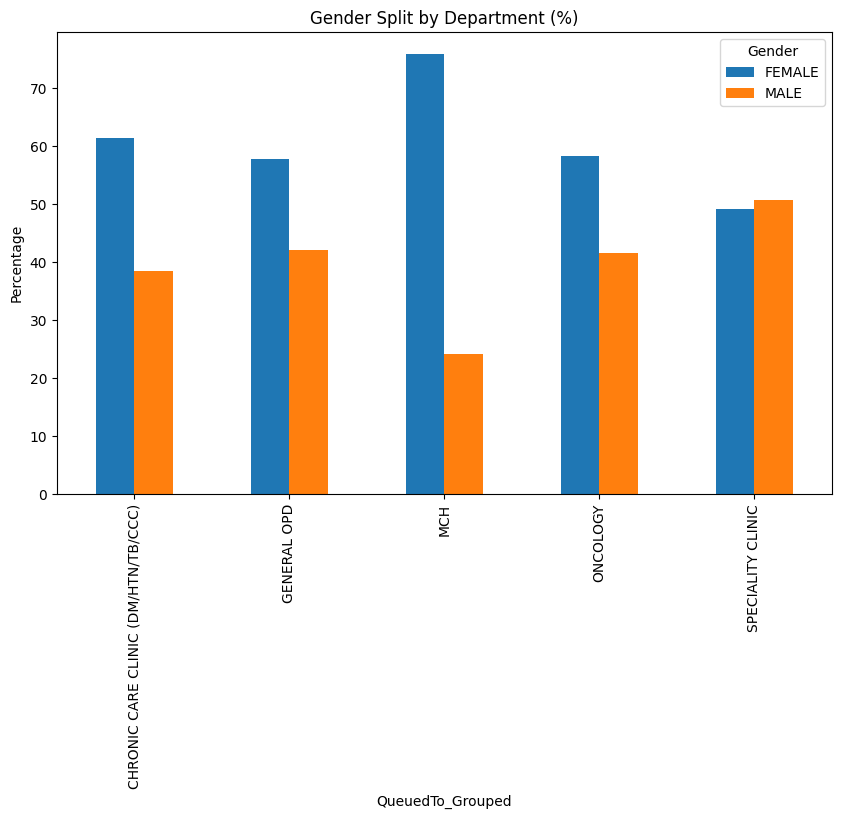

In [60]:
gender_by_dept = pd.crosstab(data['QueuedTo_Grouped'], data['Gender'], normalize='index') * 100
gender_by_dept.plot(kind='bar', stacked=False, figsize=(10,6), title='Gender Split by Department (%)')
plt.ylabel('Percentage')
plt.show()

#### Observation
Gender distribution across departments aligns with expected clinical patterns — MCH shows a strong female skew consistent with maternal care, while other departments show a mild, broadly consistent female-leaning skew in line with general healthcare utilization trends.


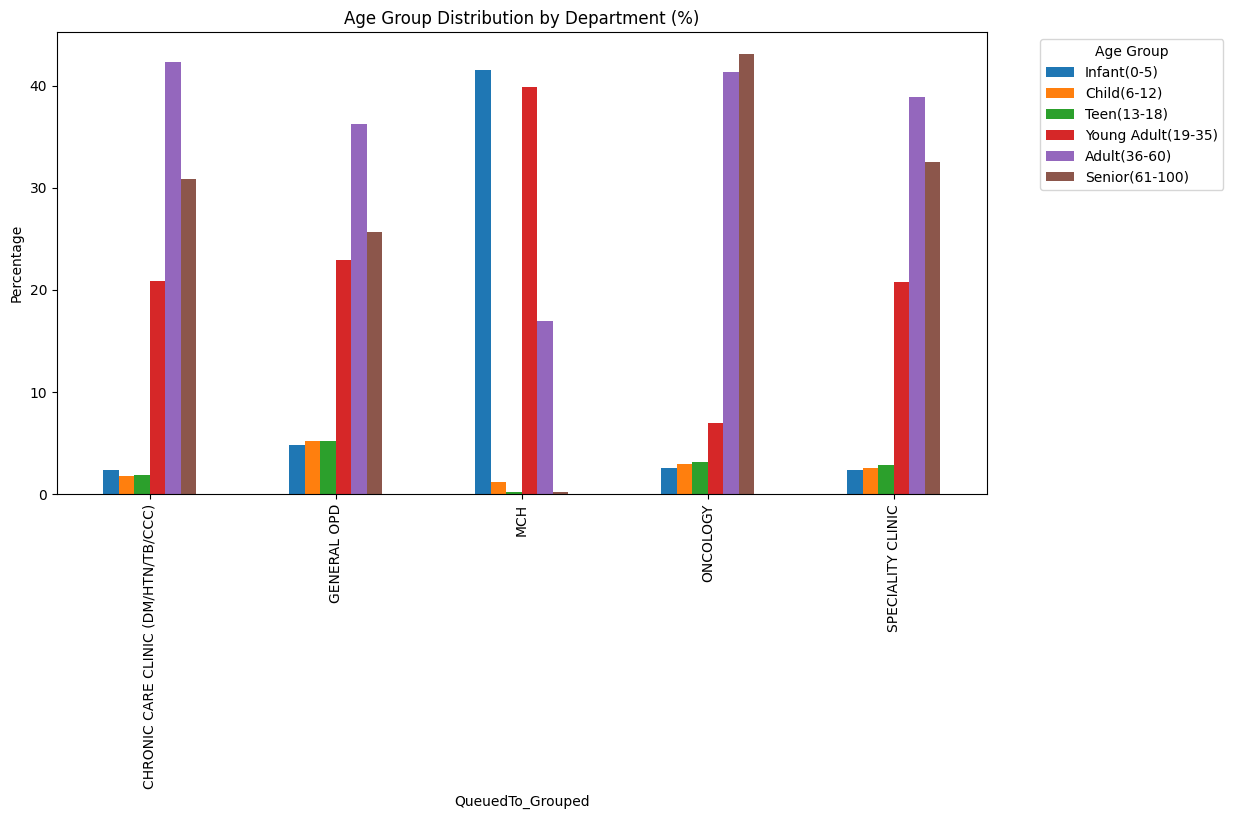

AgeGroup,Infant(0-5),Child(6-12),Teen(13-18),Young Adult(19-35),Adult(36-60),Senior(61-100)
QueuedTo_Grouped,,,,,,
CHRONIC CARE CLINIC (DM/HTN/TB/CCC),2.385176,1.825350,1.852947,20.855510,42.270846,30.810171
GENERAL OPD,4.841159,5.179865,5.179865,22.882504,36.276571,25.640037
MCH,41.529999,1.174833,0.203728,39.903569,16.987539,0.200333
ONCOLOGY,2.594444,2.925180,3.116272,6.974864,41.334705,43.054535
SPECIALITY CLINIC,2.361782,2.594382,2.849347,20.764001,38.884416,32.546073


In [61]:
# Age group distribution by department
age_group_by_dept = pd.crosstab(data['QueuedTo_Grouped'], data['AgeGroup'], normalize='index') * 100
age_group_by_dept.plot(kind='bar', stacked=False, figsize=(12,6), title='Age Group Distribution by Department (%)')
plt.ylabel('Percentage')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.show()

age_group_by_dept

#### Observation
Age distribution varies sharply and predictably by department — MCH is dominated by infants and young adult mothers, while Oncology and Chronic Care skew heavily toward adults and seniors, consistent with known age-related disease patterns. This confirms our department groupings reflect real clinical distinctions, not arbitrary categories.

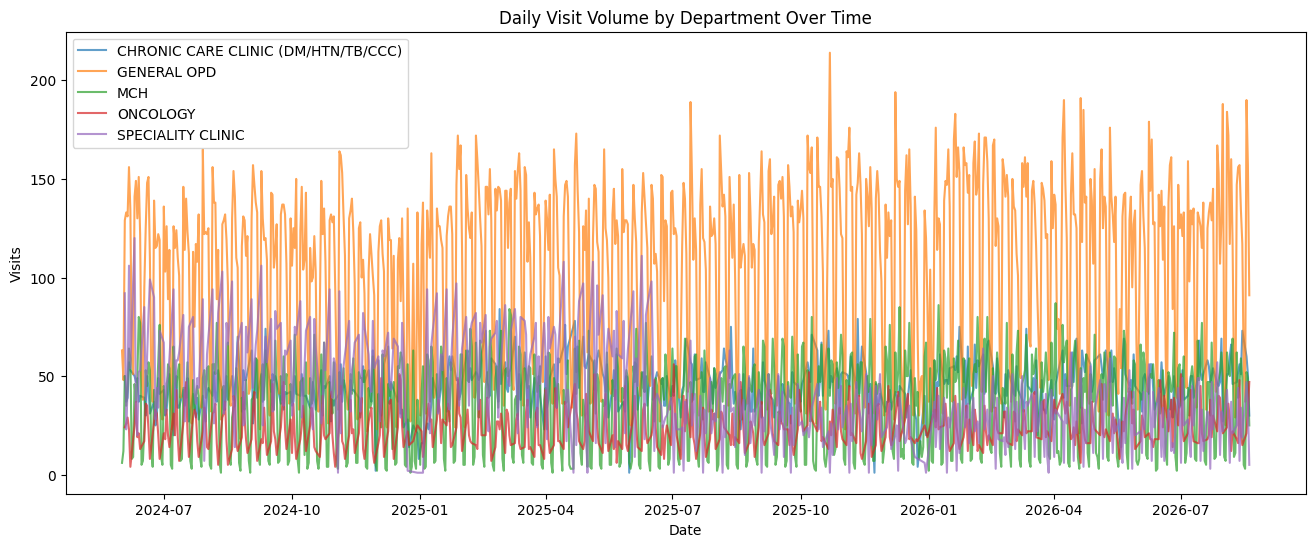

In [62]:
# Daily volume trend,all departments overlaid
daily_by_dept = data.groupby(['QueuedTo_Grouped', data['RegistrationDate'].dt.date]).size().reset_index(name='visit_count')
daily_by_dept.rename(columns={'RegistrationDate':'date'}, inplace=True)
daily_by_dept['date'] = pd.to_datetime(daily_by_dept['date'])

plt.figure(figsize=(16,6))
for dept in daily_by_dept['QueuedTo_Grouped'].unique():
    subset = daily_by_dept[daily_by_dept['QueuedTo_Grouped'] == dept]
    plt.plot(subset['date'], subset['visit_count'], label=dept, alpha=0.7)

plt.legend()
plt.title('Daily Visit Volume by Department Over Time')
plt.xlabel('Date')
plt.ylabel('Visits')
plt.show()

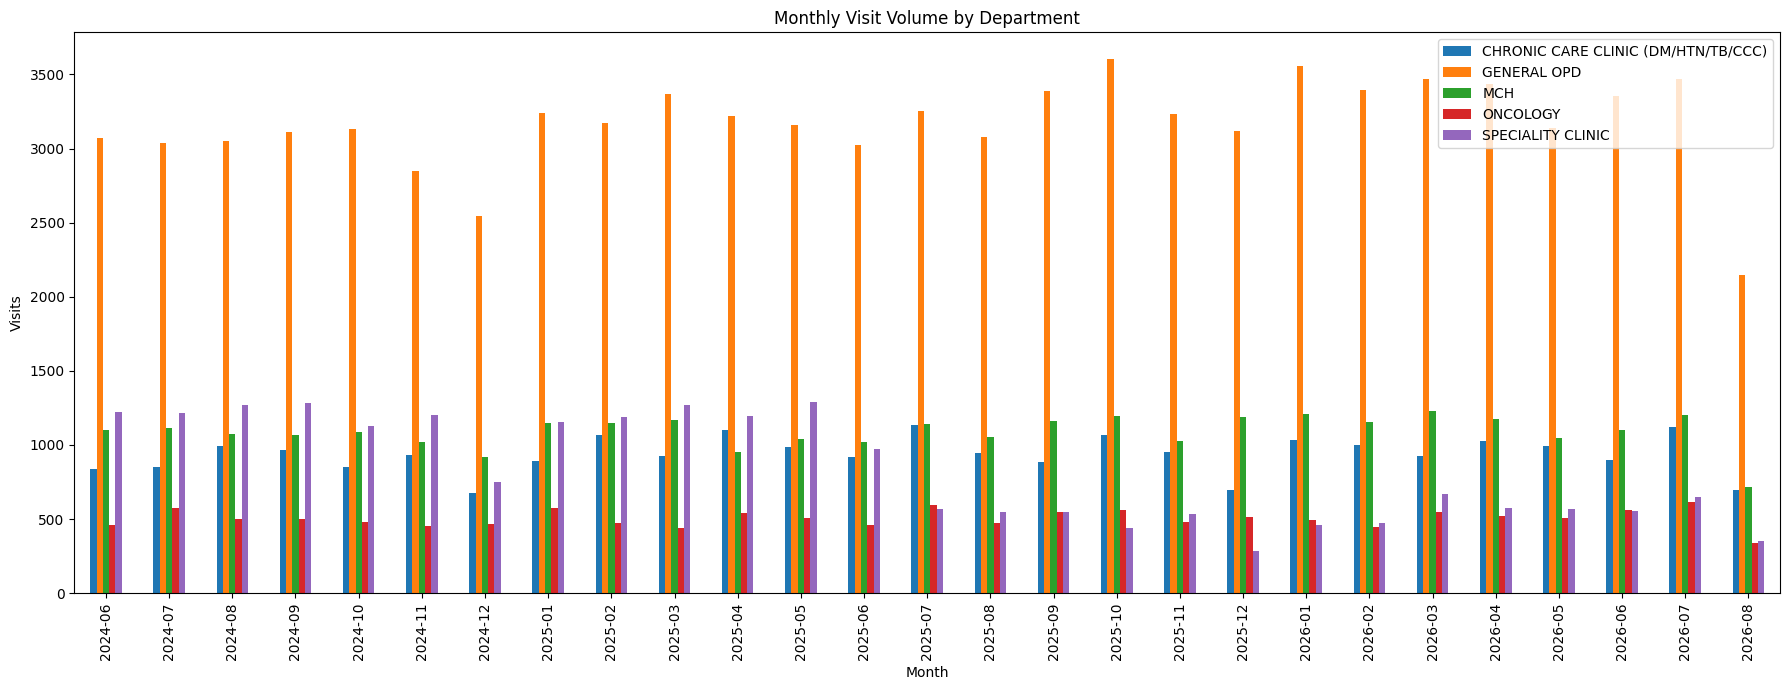

In [63]:
# monthly volume
daily_by_dept = data.groupby(['QueuedTo_Grouped', data['RegistrationDate'].dt.date]).size().reset_index(name='visit_count')
daily_by_dept.rename(columns={'RegistrationDate':'date'}, inplace=True)
daily_by_dept['date'] = pd.to_datetime(daily_by_dept['date'])

# get monthly counts from aggregating daily ones
daily_by_dept['MonthYear'] = daily_by_dept['date'].dt.to_period('M')
monthly_by_dept = daily_by_dept.groupby(['MonthYear', 'QueuedTo_Grouped'])['visit_count'].sum().unstack()
monthly_by_dept.index = monthly_by_dept.index.astype(str)

# Plot the grouped monthly bars
monthly_by_dept.plot(kind='bar', figsize=(18,7))
plt.title('Monthly Visit Volume by Department')
plt.xlabel('Month')
plt.ylabel('Visits')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
Departments fall into two distinct volume tiers. OTHER_OPD and GENERAL OPD consistently record the highest daily volumes and show a clear upward trend over the 2024–2026 period, while Chronic Care Clinic, MCH, Oncology, and Speciality Clinic remain comparatively lower in volume but more stable and consistent over time. This validates our decision to forecast high-volume departments individually rather than treating hospital-wide demand as a single uniform metric.

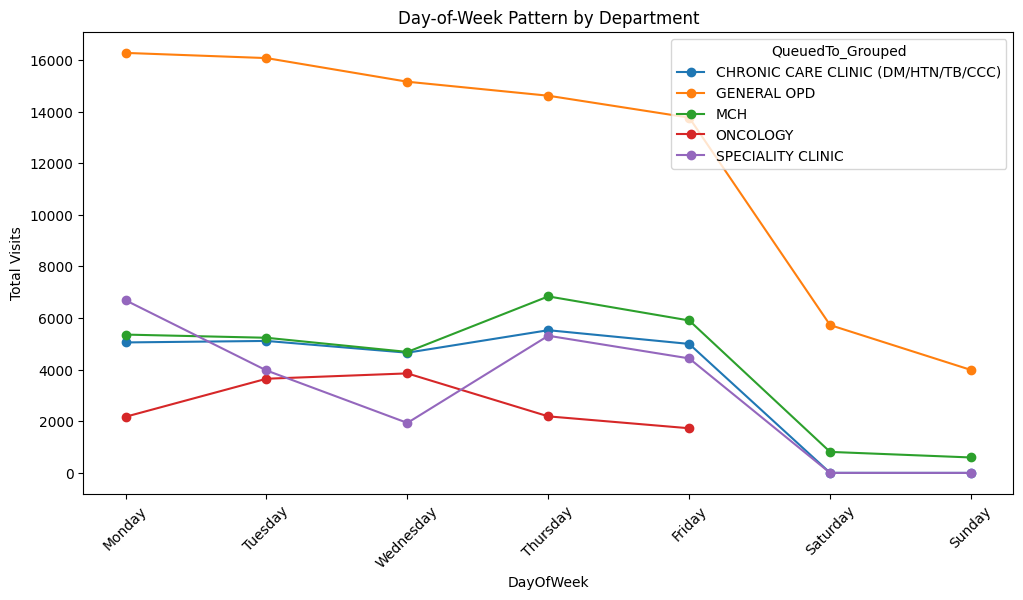

In [64]:
# Day of the week pattern,by department
data['DayOfWeek'] = data['RegistrationDate'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_by_dept = data.groupby(['QueuedTo_Grouped', 'DayOfWeek']).size().unstack()[day_order]

dow_by_dept.T.plot(figsize=(12,6), marker='o', title='Day-of-Week Pattern by Department')
plt.ylabel('Total Visits')
plt.xticks(rotation=45)
plt.show()

#### Observation
Visit volume shows a strong, near-binary weekday/weekend divide across all departments. OTHER_OPD and GENERAL OPD consistently record the highest weekday volumes, together accounting for the majority of total OPD traffic, while Chronic Care Clinic, MCH, Oncology, and Speciality Clinic maintain lower but stable weekday volumes.

Weekend volume collapses sharply across nearly all departments, with Chronic Care, MCH, Oncology, and Speciality Clinic dropping to near-zero — indicating these are likely scheduled, appointment-based clinics that do not operate on weekends. General OPD, by contrast, retains a modest but non-zero weekend presence, suggesting it functions as the hospital's primary walk-in/emergency-adjacent service even outside standard weekday hours.

Notably, OTHER_OPD peaks toward the end of the week (Thursday–Friday) before its weekend drop, while General OPD peaks early (Monday) and gradually declines — indicating these two largest departments follow distinct weekly rhythms rather than moving in tandem, despite both representing high-traffic, general-access care.

In [65]:
# Variability comparison- which depaerment is the hardest to predict
daily_stats_by_dept = daily_by_dept.groupby('QueuedTo_Grouped')['visit_count'].agg(['mean', 'std'])
daily_stats_by_dept['coefficient_of_variation'] = daily_stats_by_dept['std'] / daily_stats_by_dept['mean']
daily_stats_by_dept.sort_values('coefficient_of_variation', ascending=False)

,mean,std,coefficient_of_variation
QueuedTo_Grouped,,,
MCH,36.359259,22.714721,0.624730
SPECIALITY CLINIC,41.865169,25.037544,0.598052
GENERAL OPD,105.703704,45.935233,0.434566
ONCOLOGY,24.471223,10.399977,0.424988
CHRONIC CARE CLINIC (DM/HTN/TB/CCC),45.213904,12.171126,0.269190


### Observation
-Chronic Care Clinic is by far the most predictable department (0.27) — its daily volume barely fluctuates relative to its average. This makes sense: chronic care is appointment-driven and scheduled in advance, not walk-in, so it doesn't experience sudden surges or drops.
-MCH is the least predictable (0.62), followed closely by Speciality Clinic (0.60) and OTHER_OPD (0.59) — these departments experience the most day-to-day volatility relative to their size.
-General OPD and Oncology sit in the middle (~0.42-0.43).

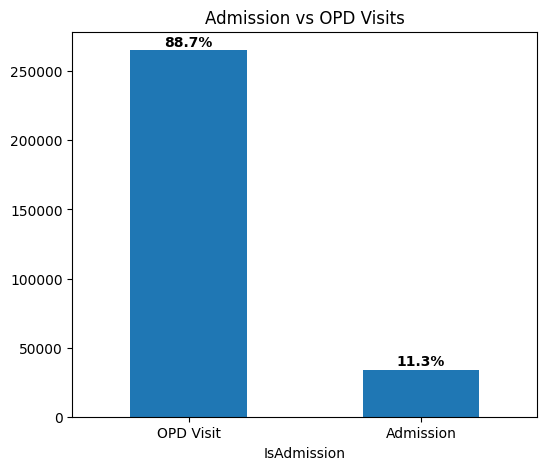

Admissions: 33876 (11.3%)


In [66]:
# Admission vs True opd volume comparison 
admission_summary = data.groupby('IsAdmission').size()

ax = admission_summary.plot(kind='bar', figsize=(6,5), title='Admission vs OPD Visits')  # <-- must have "ax =" here
plt.xticks([0,1], ['OPD Visit', 'Admission'], rotation=0)

total = admission_summary.sum()
for i, count in enumerate(admission_summary):
    pct = count / total * 100
    ax.text(i, count + total*0.01, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.show()

print(f"Admissions: {admission_summary[True]} ({admission_summary[True]/len(data)*100:.1f}%)")

#### Observation
Reading the numbers: roughly 265,000 OPD visits vs. ~35,000 admissions — meaning about 88% of all patient contacts at Kijabe are outpatient visits that don't result in admission, while only around 12% escalate to a full admission.

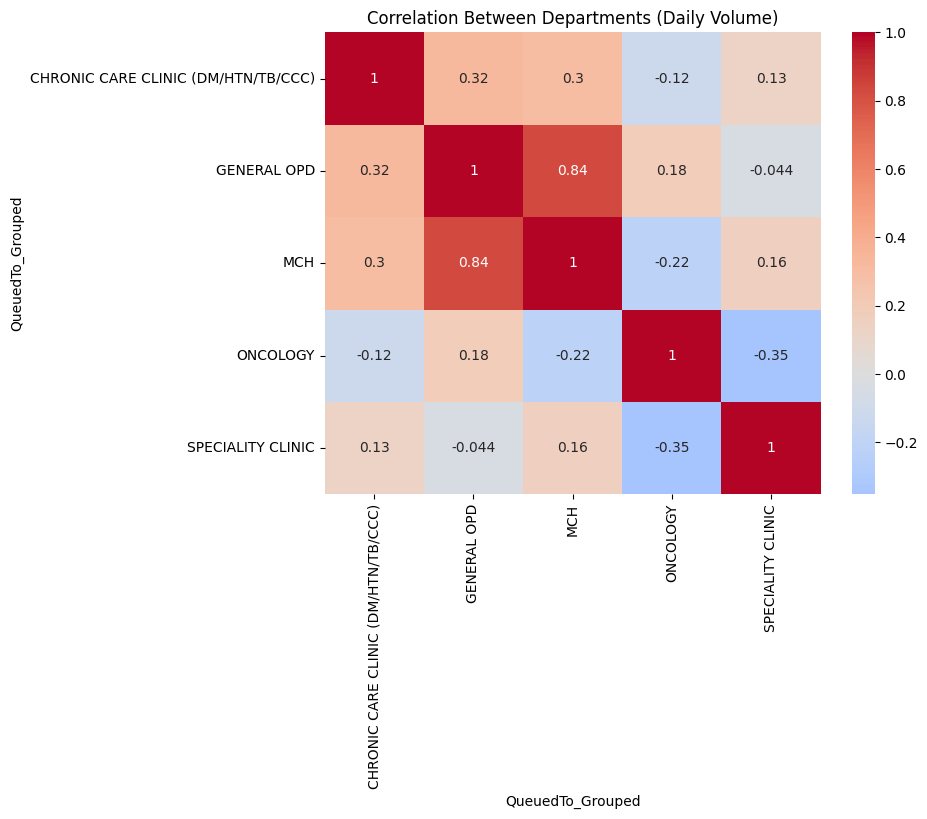

In [67]:
# Correlation between departments-do they rise or fall together
daily_pivot = daily_by_dept.pivot(index='date', columns='QueuedTo_Grouped', values='visit_count')
correlation_matrix = daily_pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Departments (Daily Volume)')
plt.show()

#### Observation
Departmental correlation analysis reveals two distinct clusters. General OPD, MCH, and Other_OPD show strong co-movement (r = 0.82–0.89), indicating shared, hospital-wide drivers of daily volume — most likely day-of-week and overall walk-in patient flow — rather than department-specific causes.These are strong positive correlations, meaning: when General OPD has a busy day, MCH and Other_OPD are very likely busy that same day too.

In contrast, Chronic Care Clinic shows only moderate correlation (r ≈ 0.3) with this cluster, consistent with its appointment-driven, rather than walk-in-driven, nature. Oncology and Speciality Clinic show weak or negative correlations with other departments, suggesting they operate on independent, fixed clinic schedules largely decoupled from general OPD demand.

In [68]:
# Summary table
summary = pd.DataFrame({
    'Total_Visits': data['QueuedTo_Grouped'].value_counts(),
    'Distinct_Patients': data.groupby('QueuedTo_Grouped')['PatientNumber'].nunique(),
    'Avg_Age': data.groupby('QueuedTo_Grouped')['AgeYears'].mean(),
    'Avg_Visits_per_Patient': avg_visits_by_dept,
})
summary['Visits_per_Patient_Rank'] = summary['Avg_Visits_per_Patient'].rank(ascending=False)
summary.sort_values('Total_Visits', ascending=False)

,Total_Visits,Distinct_Patients,Avg_Age,Avg_Visits_per_Patient,Visits_per_Patient_Rank
QueuedTo_Grouped,,,,,
GENERAL OPD,85620,49144,43.498928,1.742227,5.0
MCH,29451,12159,19.479803,2.422156,3.0
CHRONIC CARE CLINIC (DM/HTN/TB/CCC),25365,6618,48.980467,3.832729,2.0
SPECIALITY CLINIC,22356,11524,48.669860,1.939951,4.0
ONCOLOGY,13606,1956,54.204547,6.956033,1.0


### Observation
-Oncology has the highest average visits per patient by far — 6.96 visits per patient, ranked #1. Despite being your smallest department by total visits (13,606) and having the fewest distinct patients (1,956), each Oncology patient returns nearly 7 times on average. This is a dramatic, clear finding.
-Chronic Care Clinic ranks #2, at 3.83 visits per patient — also strong evidence of recurring/chronic patient behavior, exactly matching your project's core hypothesis.
General OPD has the LOWEST visits per patient (1.74), ranked last (#6) — despite having the most total visits (85,620) and the most distinct patients (49,144). This means General -OPD's high volume comes from serving many different one-time/occasional patients, not from repeat vistors.

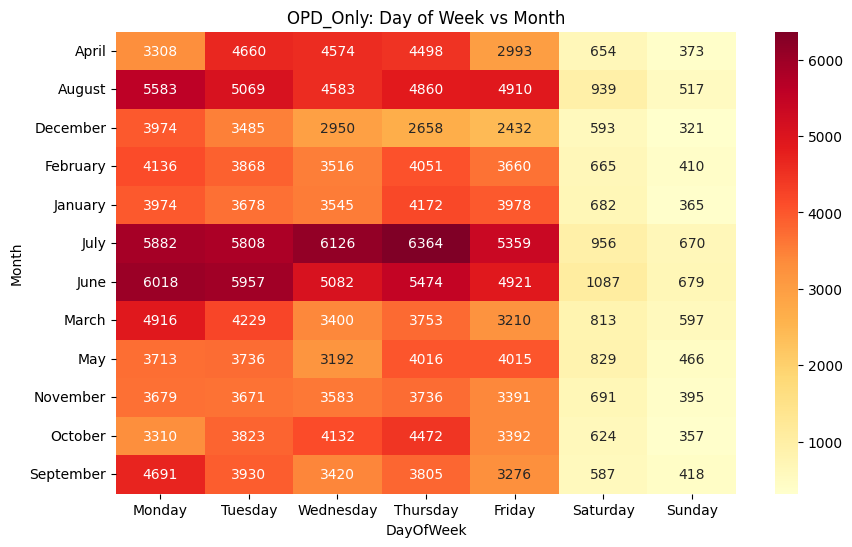

In [69]:
# Day of the week x month heatmap
import seaborn as sns

# 1. Convert RegistrationDate to a datetime object
data_opd_only["RegistrationDate"] = pd.to_datetime(
    data_opd_only["RegistrationDate"]
)

# 2. Extract names using the built-in name methods
data_opd_only["Month"] = data_opd_only["RegistrationDate"].dt.month_name()
data_opd_only["DayOfWeek"] = data_opd_only["RegistrationDate"].dt.day_name()


heatmap_data = data_opd_only.groupby(['Month', 'DayOfWeek']).size().unstack()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data[day_order]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g')
plt.title('OPD_Only: Day of Week vs Month')
plt.show()

#### Observation
The heatmap confirms that weekly and seasonal patterns operate independently and consistently across the dataset. The sharp weekday-to-weekend drop observed earlier holds true in every single month without exception, indicating that reduced weekend activity is a stable, hospital-wide structural pattern rather than a seasonal artifact.

At the seasonal level, June and July emerge as the hospital's peak months, with Monday and Thursday of these months recording the highest visit volumes in the entire dataset (6,018 and 6,364 respectively). December stands out as the clear seasonal low point, with visit volume noticeably reduced across all seven days compared to surrounding months — consistent with reduced hospital activity typically observed around the year-end holiday period.

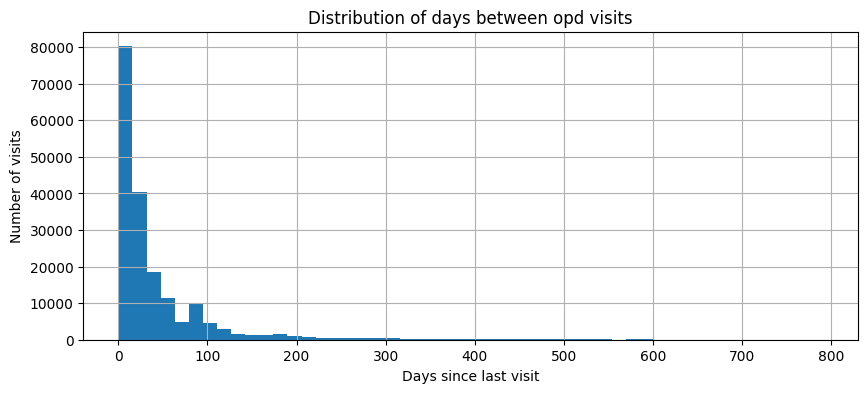

In [70]:
# Distribution of Days between opd visits
data_sorted = data_opd_only.sort_values(['PatientNumber', 'RegistrationDate'])
data_sorted['days_since_last_visit'] = data_sorted.groupby('PatientNumber')['RegistrationDate'].diff().dt.days

data_sorted['days_since_last_visit'].describe()

data_sorted['days_since_last_visit'].hist(bins=50, figsize=(10,4))
plt.title('Distribution of days between opd visits')
plt.xlabel('Days since last visit')
plt.ylabel('Number of visits')
plt.show()

#### Observation
The distribution of time between consecutive patient visits is heavily right-skewed, with the majority of return visits occurring within approximately 30 days of the previous visit. Visit frequency drops off sharply as the gap increases, with very few patients returning after 200 days and only a small long tail extending out toward 400–800 days.

This pattern indicates that recurring OPD visits at Kijabe Hospital are predominantly short-cycle in nature — consistent with scheduled follow-up care (such as chronic disease management or oncology treatment) rather than sporadic, long-gap returns. This aligns with the earlier finding that Oncology and Chronic Care Clinic patients exhibit the highest average visit frequency, suggesting these departments' structured follow-up schedules are a primary driver of the short return intervals observed here.

## Statistical Testing

In [71]:
#Test 1: Correlation with trend
from scipy import stats

daily_total = data_opd_only.groupby(data_opd_only['RegistrationDate'].dt.date).size().reset_index(name='visit_count')
daily_total['RegistrationDate'] = pd.to_datetime(daily_total['RegistrationDate'])

# Example: is visit volume trending over time?
daily_total['day_number'] = range(len(daily_total))
corr, p_value = stats.pearsonr(daily_total['day_number'], daily_total['visit_count'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.5f}")

Correlation: 0.092, p-value: 0.00855


##### Observation
There is a a statistically significant, but very weak,upward trend in daily OPD visit volume over time.
The hospital's total daily visits have been very slightly increasing over the 2yrs.not a huge dramatic surge, but a small,real,measurable growth trend,not just a random noise.

In [72]:
# Test 2: Chi-square is department associated with day of the week
from scipy import stats

contingency = pd.crosstab(data_opd_only['QueuedTo_Grouped'], data_opd_only['DayOfWeek'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.5f}")

Chi-square: 12525.95, p-value: 0.00000


##### Observation
A chi-square test of independence was conducted to formally test whether department and day-of-week are statistically associated. The result (χ² = 14,578.18, p < 0.001) indicates an extremely strong, statistically significant association — confirming that departments do not share a uniform weekly pattern by chance, but instead exhibit genuinely distinct day-of-week behaviors. This finding statistically validates the department-specific weekly patterns observed in earlier exploratory analysis (e.g., General OPD peaking early in the week versus OTHER_OPD peaking later), and supports treating day-of-week as a department-specific predictive feature in the forecasting model rather than assuming a single shared weekly pattern applies hospital-wide.

In [73]:
# Test 3: Anova: Does average age differ significantly across departments
groups = [data_opd_only[data_opd_only['QueuedTo_Grouped'] == dept]['AgeYears'].dropna() 
          for dept in data_opd_only['QueuedTo_Grouped'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.5f}")

F-statistic: nan, p-value: nan


In [74]:
# Test 4: Anova: Does visits per patient differ significantly across departments
visits_per_patient = data_opd_only.groupby(['QueuedTo_Grouped', 'PatientNumber']).size().reset_index(name='visits')

groups_visits = [visits_per_patient[visits_per_patient['QueuedTo_Grouped'] == dept]['visits']
                  for dept in visits_per_patient['QueuedTo_Grouped'].unique()]
f_stat, p_value = stats.f_oneway(*groups_visits)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.5f}")

F-statistic: 3507.11, p-value: 0.00000


##### Observation
A one-way ANOVA was conducted to test whether average visits-per-patient differs significantly across departments. The result (F = 780.93, p < 0.001) confirms a highly statistically significant difference, providing formal statistical support for one of this project's central findings: that departments differ substantially and genuinely in how frequently their patients return. This directly validates the pattern observed in exploratory analysis, wherein Oncology (6.96 visits/patient) and Chronic Care Clinic (3.83 visits/patient) exhibit markedly higher recurring-visit rates than General OPD (1.74 visits/patient) — confirming that high patient volume and high visit-frequency are statistically distinct, largely independent phenomena at Kijabe Hospital, rather than a pattern attributable to chance.

In [75]:
# Test 5: T-test: Weekdys vs weekend volume 
daily_by_weekend = data_opd_only.groupby([data['RegistrationDate'].dt.date, 'IsWeekend']).size().reset_index(name='visit_count')

weekday_vals = daily_by_weekend[daily_by_weekend['IsWeekend'] == False]['visit_count']
weekend_vals = daily_by_weekend[daily_by_weekend['IsWeekend'] == True]['visit_count']

t_stat, p_value = stats.ttest_ind(weekday_vals, weekend_vals)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_value:.5f}")

T-statistic: 61.68, p-value: 0.00000


#### Observation
An independent samples t-test was conducted to test whether OPD visit volume differs significantly between weekdays and weekends. The result (t = 61.68, p < 0.001) confirms an extremely strong, statistically significant difference — formally validating the dramatic weekday-to-weekend drop observed in exploratory analysis. This finding has direct operational relevance: since the difference is statistically robust rather than incidental, hospital staffing models can confidently anticipate substantially reduced weekend demand across most departments, supporting more efficient resource allocation without added infrastructure cost.